## State Estimation (With data from publicly available dataset Leg-KILO)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from utils.plot_data import *
from tqdm import tqdm
from rosbags.highlevel import AnyReader
from rosbags.typesys import get_typestore, Stores
from utils.ekf_utils import *

In [13]:
from utils.ros_bag import *
from pathlib import Path

https://github.com/ShuoYangRobotics/Cerberus

Interesting topics:
- **/hardware_a1/imu**: internal robot IMU (raw)
    - orientation, angular_velocity, linear acceleration (filtered)
- **/imu/data**: sensorfusion, orientation computed from gyro and acc
    - orientation, angular_velocity, linear acceleration
- **/hardware_a1/joint_foot**
    - name, position, velocity
- **/mocap_node/mocap/pose**
    -pose.position, pose.orientation

---

Not existing:
- contact_forces (maybe in joint_foot last 4 of effort)
- contact_state (can be estimated as contact_state = force > threshold)
- contact_pos 

https://github.com/ouguangjun/legkilo-dataset

Interesting topics:
- **/high_state**

#### Inspect ROS file

In [4]:
bagpath = Path("../custom_datasets/corridor.bag")
inspect_rosbag_file(bagpath)

============================== Topics ==============================
/high_state                               unitree_legged_msgs/msg/HighState
/state_SDK                                nav_msgs/msg/Odometry
/imu_raw                                  sensor_msgs/msg/Imu
/points_raw                               sensor_msgs/msg/PointCloud2

==================== Example for /high_state (unitree_legged_msgs/msg/HighState) ====================
stamp.sec = 1684325646
stamp.nanosec = 562455592
stamp.__msgtype__ = builtin_interfaces/msg/Time
head = [254 239]
levelFlag = 238
frameReserve = 0
SN = [100729604     66077]
version = [    590080 2146969345]
bandWidth = 250
imu.quaternion = [-0.01335226  0.01234161 -0.7031739   0.71078545]
imu.gyroscope = [-0.00191184 -0.01583053 -0.00426268]
imu.accelerometer = [ 1.1971008e-03 -3.1723171e-01  9.6558151e+00]
imu.rpy = [-3.6345810e-02 -1.2334518e-03 -1.5600076e+00]
imu.temperature = 79
imu.__msgtype__ = unitree_legged_msgs/msg/IMU
motorState = [unitre

#### Read ROS file

In [ ]:
bagpath = Path("../custom_datasets/corridor.bag")
save_path = Path.cwd().parent / "results/leg-kilo"
file_name = "leg-kilo-data_corridor"

read_rosbag_file(bagpath=bagpath,
                 outpur_dir=save_path,
                 file_name=file_name,
                 order=[3,4,5, 0,1,2, 6,7,8, 9,10,11])

Reading ROS .bag file: 100%|██████████| 670538/670538 [00:25<00:00, 26052.75it/s]


#### Load ROS file

In [7]:
save_path = Path.cwd().parent / "results/leg-kilo"
file_name = "leg-kilo-data_corridor"

leg_kilo_data = np.load(f"{save_path}/{file_name}.npz")

#### Leg KILO plots

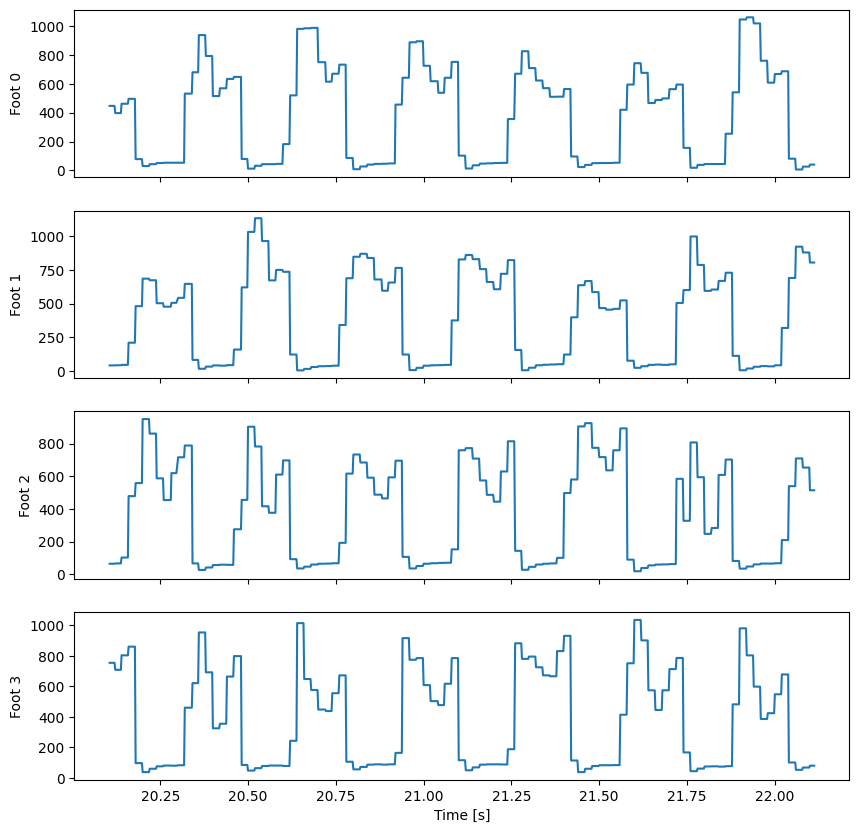

In [9]:
force_np = np.array(leg_kilo_data["foot_force"])
time_state = np.array(leg_kilo_data["time_state"])
time_state -= time_state[0]

fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10,10))

for i in range(4):
    axs[i].plot(time_state[10000:11000], force_np[10000:11000, i])
    axs[i].set_ylabel(f'Foot {i}')

axs[-1].set_xlabel('Time [s]')

# plt.tight_layout()
plt.show()

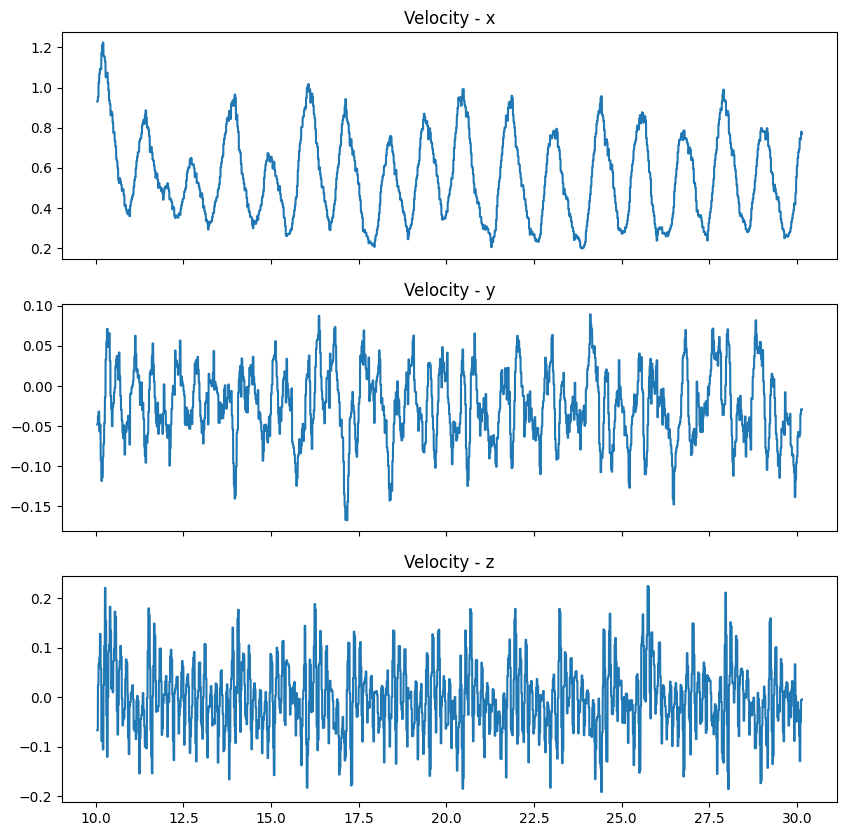

In [10]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10,10))
time_state = np.array(leg_kilo_data["time_state"])
time_state -= time_state[0]

dim = ["x", "y", "z"]
for i in range(3):
    axs[i].plot(time_state[5000:15000], leg_kilo_data["base_vel"][5000:15000, i])
    axs[i].set_title(f"Velocity - {dim[i]}")

plt.show()

#### State estimation

In [15]:
dt = compute_mean_dt(time_states=leg_kilo_data["time_state"])
print(f"mean dt: {dt}")

mean dt: 0.002


In [16]:
num_data_points = 10000
results_leg_kilo_est = run_state_estimation(dt=dt,
                                            base_orient=leg_kilo_data['base_orient'][:num_data_points],        # world frame
                                            base_ang_vel=leg_kilo_data['base_ang_vel'][:num_data_points],      # body frame
                                            joint_pos=leg_kilo_data['joint_pos'][:num_data_points],            # joint frame
                                            joint_vel=leg_kilo_data['joint_vel'][:num_data_points],            # joint frame
                                            joint_torque=leg_kilo_data['joint_torque'][:num_data_points],      # joint frame
                                            contact_forces=leg_kilo_data['foot_force'][:num_data_points],
                                            contact_pos=leg_kilo_data['contact_pos'][:num_data_points],        # body frame
                                            contact_state_threshold=100,
                                            Q=0.0001,
                                            R=[0.1, 0.1, 0.1])

Estimating base_acc.
Estimating contact state from contact_force and threshold


/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jad/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Estimating state:   1%|▏         | 133/10000 [00:00<00:14, 663.52it/s]

Estimating contact_force from estimated contact_state and joint torque


Estimating state: 100%|██████████| 10000/10000 [00:19<00:00, 512.60it/s]


#### Save estimation

In [24]:
result_dir="results/leg-kilo"
file_name="leg-kilo_Q-0.0001_R-1"
save_path = Path.cwd().parent / result_dir
save_path.mkdir(parents=True, exist_ok=True)

In [25]:
np.savez(f"{save_path}/{file_name}.npz", **results_leg_kilo_est)

In [26]:
results_leg_kilo_est = np.load(f"{save_path}/{file_name}.npz")

#### Plot estimation

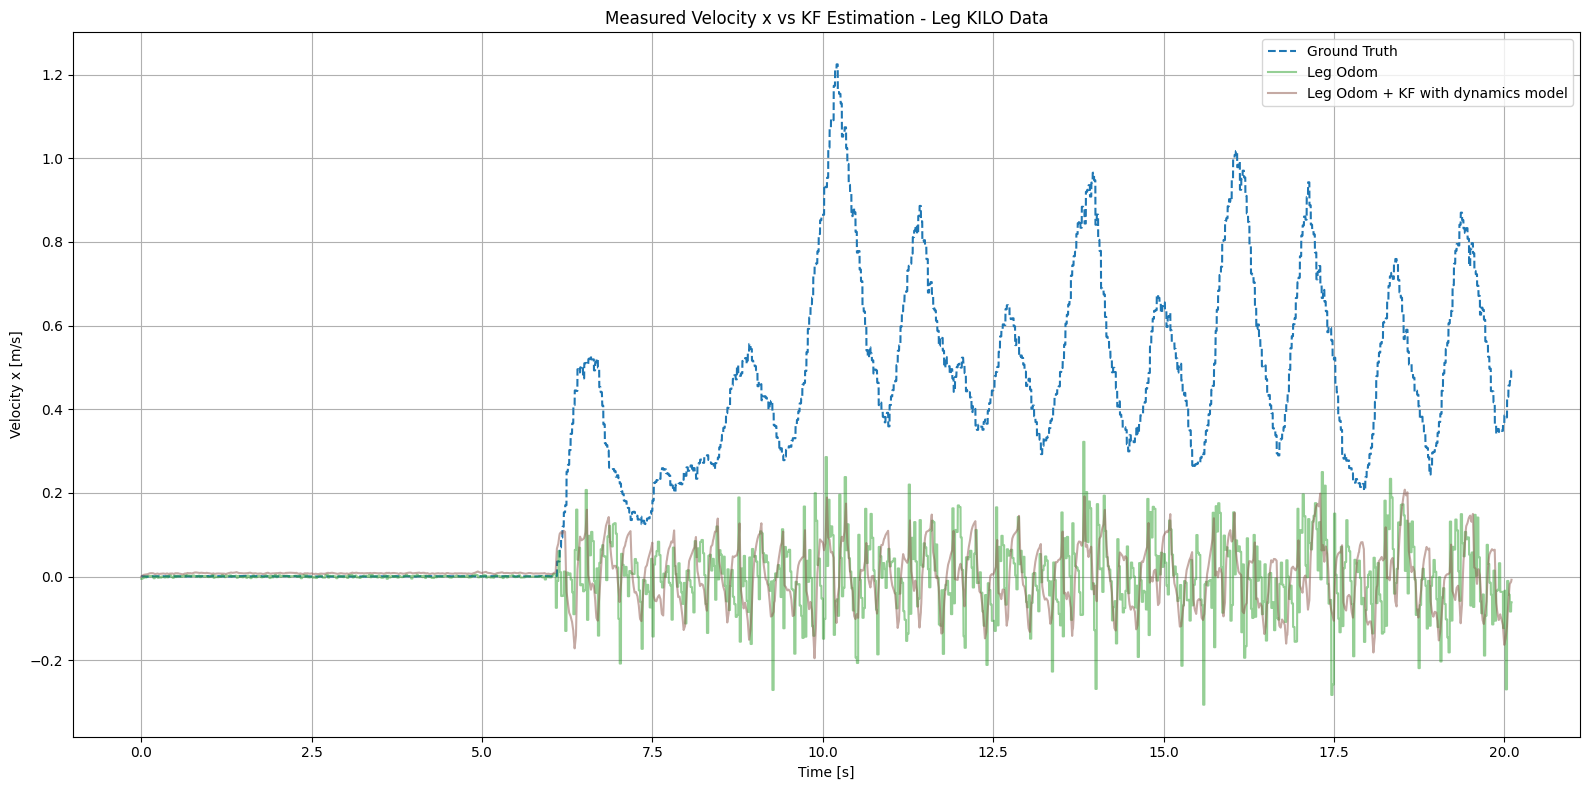

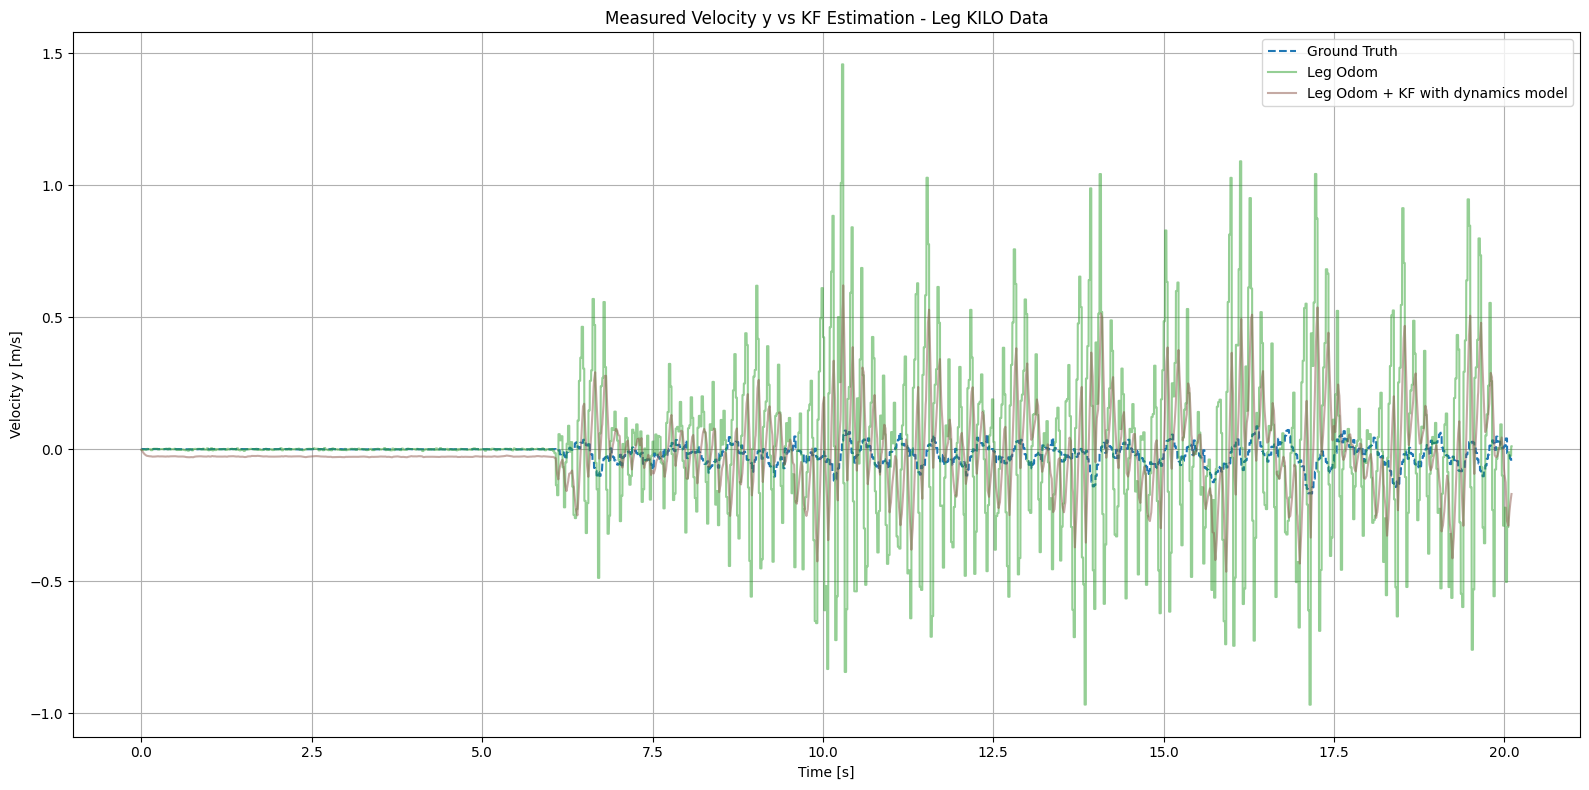

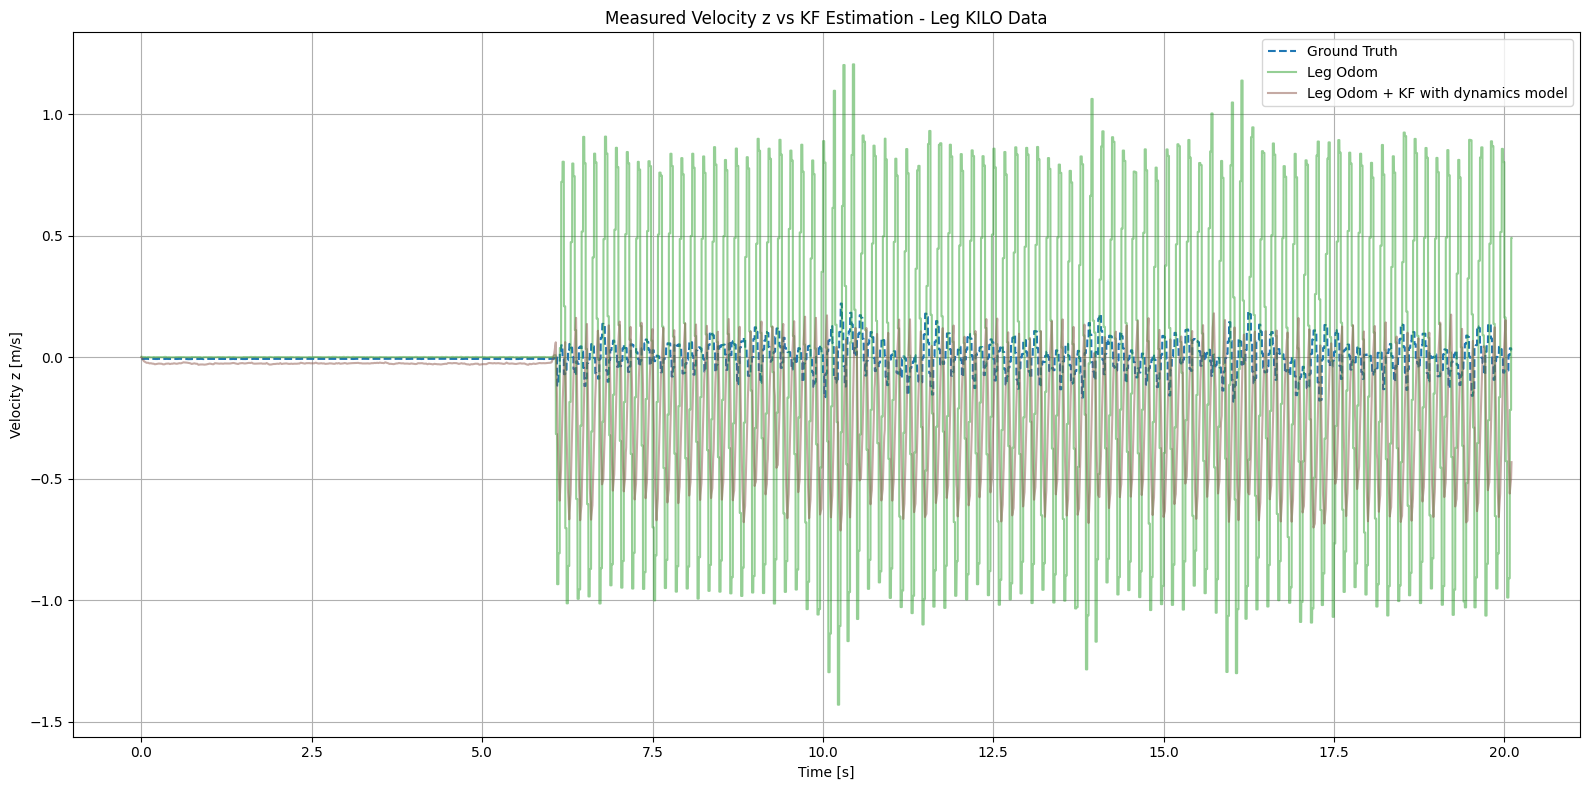

In [17]:
colors = ['#1f77b4', # gt
        # '#ff7f0e', # gt_acc
        '#2ca02c', # leg odom
        # '#d62728', # leg odom + kf, acc=0
        # '#9467bd', # leg odom + kf, dynamics
        '#8c564b'  # leg odom + kf, dynamics with est cf
        ]

dim = ["x", "y", "z"]
time_state = leg_kilo_data["time_state"]
time_state -= time_state[0]

num_data_points = 10000

for i in range(len(dim)):
    gt_values = leg_kilo_data["base_vel"][:num_data_points, i:i+1]

    pred_values = [results_leg_kilo_est["leg_odom"][:num_data_points, i:i+1],
                   results_leg_kilo_est["vel_update"][:num_data_points, i:i+1]]

    pred_labels = ["Leg Odom",
                   "Leg Odom + KF with dynamics model"]

    compare_estimation_plot(time=time_state[:num_data_points],
                            gt_values=gt_values,
                            gt_label=["Ground Truth"],
                            pred_values=pred_values,
                            pred_labels=pred_labels,
                            ylabel=f"Velocity {dim[i]} [m/s]",
                            title=f"Measured Velocity {dim[i]} vs KF Estimation - Leg KILO Data",
                            colors=colors,
                        #     output_folder=Path.cwd().parent.as_posix() + "/results/leg-kilo",
                        #     file_name=f"Leg_KILO_result_{dim[i]}",
                        #     file_types=["png"]
                            )